## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D) 

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들) 
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import pandas as pd

torch.Size([28, 28])


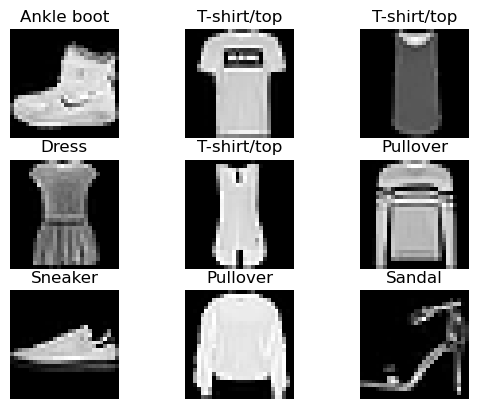

In [3]:
_preview = datasets.FashionMNIST('./data/', train=True, download=True)
_classes = _preview.classes

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(_preview.data[i], cmap='gray')
    plt.title(_classes[_preview.targets[i]])
    plt.axis('off')

print(_preview.data[0].shape)  # (28, 28) - 흑백 1채널
plt.show()

In [4]:
from torch.utils.data import Dataset

class CustomFashionMNIST(Dataset):
    def __init__(self, root, train=True, download=False):
        self.base_dataset = datasets.FashionMNIST(
            root=root, train=train, download=download
        )
        self.train = train

        self.train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(28, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
       
        self.test_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.train_transform(image)
        else:
            image = self.test_transform(image)

        return image, int(label)

train_data = CustomFashionMNIST(root='./data/', train=True, download=True)
test_data = CustomFashionMNIST(root='./data/', train=False, download=True)

## Modeling

In [5]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim,
                 use_bn=True, dropout_p=0.0, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3,
                                stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim) if use_bn else nn.Identity()
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout2d(dropout_p)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        return x

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes, use_bn=True, dropout_p=0.0):
        super(CNN, self).__init__()
        
        self.block1 = BasicBlock(1, 32, 16, use_bn, dropout_p)
        self.block2 = BasicBlock(32, 128, 64, use_bn, dropout_p)
        self.block3 = BasicBlock(128, 256, 128, use_bn, dropout_p)

        self.fc1 = nn.Linear(in_features=2304, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [7]:
dummy = torch.zeros(1, 1, 28, 28)
x = BasicBlock(1, 32, 16)(dummy)
x = BasicBlock(32, 128, 64)(x)
x = BasicBlock(128, 256, 128)(x)
print(x.shape)  # torch.Size([1, 256, 3, 3])

torch.Size([1, 256, 3, 3])


In [8]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device 정보: {device}")

# 결과 저장 경로
SAVE_DIR = r"C:\Users\user\Desktop\kubig\assignment_5"
os.makedirs(SAVE_DIR, exist_ok=True)

device 정보: cuda


In [9]:
def run_experiment(exp_name, use_bn, dropout_p, optimizer_name, lr,
                    max_epochs=100, patience=5):

    model = CNN(num_classes=10, use_bn=use_bn, dropout_p=dropout_p)
    model.to(device)

    if optimizer_name == "adam":
        optim = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif optimizer_name == "sgd":
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    ckpt_path = os.path.join(SAVE_DIR, f"best_model_{exp_name}.pth")

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        for data, label in tqdm(train_loader, desc=f"[{exp_name}] epoch{epoch+1}"):
            optim.zero_grad()
            preds = model(data.to(device))
            loss = nn.CrossEntropyLoss()(preds, label.to(device))
            loss.backward()
            optim.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_loader)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, label in test_loader:
                preds = model(data.to(device))
                val_loss += nn.CrossEntropyLoss()(preds, label.to(device)).item()
        val_loss /= len(test_loader)
        val_losses.append(val_loss)

        print(f"[{exp_name}] epoch{epoch+1} train_loss:{epoch_loss:.4f} val_loss:{val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{exp_name}] Early stopping at epoch {epoch+1}")
                break

    # ---- 최종 accuracy 계산 (best 모델 기준) ---- #
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    num_corr = 0
    with torch.no_grad():
        for data, label in test_loader:
            output = model(data.to(device))
            preds = output.data.max(1)[1]
            num_corr += preds.eq(label.to(device).data).sum().item()
    accuracy = num_corr / len(test_data)

    # ---- 그래프 저장 ---- #
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
    plt.title(f'{exp_name} (acc={accuracy:.4f})')
    fig_path = os.path.join(SAVE_DIR, f"{exp_name}_loss_curve.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()

    return {
        "exp_name": exp_name,
        "use_bn": use_bn,
        "dropout_p": dropout_p,
        "optimizer": optimizer_name,
        "lr": lr,
        "epochs_ran": len(train_losses),
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "best_val_loss": best_val_loss,
        "test_accuracy": accuracy,
        "train_losses": train_losses,
        "val_losses": val_losses,  
    }

[exp1_baseline] epoch1: 100%|██████████| 938/938 [00:13<00:00, 72.07it/s]


[exp1_baseline] epoch1 train_loss:0.6875 val_loss:0.3767


[exp1_baseline] epoch2: 100%|██████████| 938/938 [00:13<00:00, 67.63it/s]


[exp1_baseline] epoch2 train_loss:0.3944 val_loss:0.3773


[exp1_baseline] epoch3: 100%|██████████| 938/938 [00:13<00:00, 67.99it/s]


...

[exp4_bn_dropout_sgd] epoch37: 100%|██████████| 938/938 [00:15<00:00, 59.46it/s]


[exp4_bn_dropout_sgd] epoch37 train_loss:0.2397 val_loss:0.2030


[exp4_bn_dropout_sgd] epoch38: 100%|██████████| 938/938 [00:15<00:00, 60.33it/s]


[exp4_bn_dropout_sgd] epoch38 train_loss:0.2402 val_loss:0.2088
[exp4_bn_dropout_sgd] Early stopping at epoch 38
              exp_name  use_bn  dropout_p optimizer     lr  epochs_ran  \
0        exp1_baseline   False        0.0      adam  0.001          22   
1              exp2_bn    True        0.0      adam  0.001          22   
2      exp3_bn_dropout    True        0.3      adam  0.001          28   
3  exp4_bn_dropout_sgd    True        0.3       sgd  0.010          38   

   final_train_loss  final_val_loss  best_val_loss  test_accuracy  
0          0.186700        0.212443       0.199484         0.9287  
1          0.178769        0.215386       0.191857         0.9307  
2          0.263785        0.222778       0.213578         0.9219  
3          0.240227        0.208790       0.199965         0.9267  

요약 CSV 저장 완료: C:\Users\user\Desktop\kubig\assignment_5\experiment_summary.csv


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_150700\2387187983.py:32: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  plt.savefig(compare_path, dpi=150, bbox_inches='tight')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_150700\2387187983.py:32: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from current font.
  plt.savefig(compare_path, dpi=150, bbox_inches='tight')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_150700\2387187983.py:32: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.savefig(compare_path, dpi=150, bbox_inches='tight')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_150700\2387187983.py:32: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.savefig(compare_path, dpi=150, bbox_inches='tight')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_150700\2387187983.py:32: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}

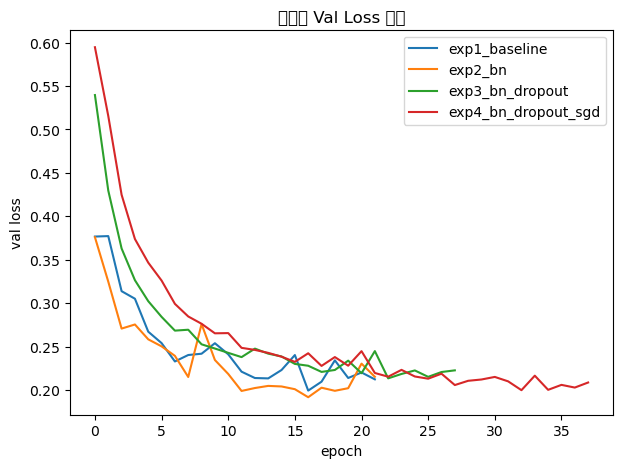

In [10]:
# 실험 설정 목록
experiments = [
    dict(exp_name="exp1_baseline",     use_bn=False, dropout_p=0.0, optimizer_name="adam", lr=1e-3),
    dict(exp_name="exp2_bn",           use_bn=True,  dropout_p=0.0, optimizer_name="adam", lr=1e-3),
    dict(exp_name="exp3_bn_dropout",   use_bn=True,  dropout_p=0.3, optimizer_name="adam", lr=1e-3),
    dict(exp_name="exp4_bn_dropout_sgd", use_bn=True, dropout_p=0.3, optimizer_name="sgd", lr=1e-2),
]

results = []
for cfg in experiments:
    result = run_experiment(**cfg, max_epochs=100, patience=5)
    results.append(result)

# CSV 저장용 요약표 (train_losses/val_losses 리스트는 제외하고 저장)
summary_only = [
    {k: v for k, v in r.items() if k not in ("train_losses", "val_losses")}
    for r in results
]
results_df = pd.DataFrame(summary_only)
csv_path = os.path.join(SAVE_DIR, "experiment_summary.csv")
results_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(results_df)
print(f"\n요약 CSV 저장 완료: {csv_path}")

# 실험별 val loss 비교 그래프
plt.figure(figsize=(7,5))
for r in results:
    plt.plot(r["val_losses"], label=r["exp_name"])
plt.xlabel('epoch'); plt.ylabel('val loss'); plt.legend()
plt.title('실험별 Val Loss 비교')
compare_path = os.path.join(SAVE_DIR, "comparison_val_loss.png")
plt.savefig(compare_path, dpi=150, bbox_inches='tight')
plt.show()